<a href="https://colab.research.google.com/github/acorrealama/DL-Final-Correa-Arturo/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Churn Bancario con Deep Learning

**Nombre:** Apellido, Nombre  
**Curso:** Modelos de Deep Learning: Aplicaciones Prácticas  
**Institución:** Centrum PUCP

---

## 1. Problema y Objetivo del Proyecto

El **churn bancario** ocurre cuando un cliente decide cerrar su cuenta y dejar de usar los servicios del banco. Retener a un cliente existente es significativamente más barato que adquirir uno nuevo, por lo que predecir qué clientes están en riesgo de irse tiene un alto valor para la toma de decisiones comerciales.

**Objetivo:** Construir una Red Neuronal Multicapa (MLP) con Keras/TensorFlow que prediga si un cliente abandonará el banco (churn = 1) o se quedará (churn = 0), basándose en sus características demográficas y de comportamiento bancario.

**¿Por qué Deep Learning?** A diferencia de los modelos de Machine Learning clásico, una red neuronal puede aprender representaciones complejas y no lineales de los datos de forma automática, sin necesidad de definir manualmente las relaciones entre variables. Esto la convierte en una herramienta poderosa para problemas donde las interacciones entre variables son difíciles de modelar explícitamente.

**Valor para el negocio:** Con este modelo, el área comercial puede identificar clientes en riesgo con anticipación y tomar acciones preventivas como ofertas personalizadas, llamadas de retención o mejora de condiciones contractuales.

## 2. Dataset Utilizado

Se utiliza el **Churn Modelling Dataset**, disponible públicamente en Kaggle. Contiene información de **10,000 clientes** de un banco europeo con las siguientes variables:

| Variable | Descripción |
|---|---|
| CreditScore | Puntaje crediticio del cliente |
| Geography | País del cliente (Francia, Alemania, España) |
| Gender | Género del cliente |
| Age | Edad del cliente |
| Tenure | Años como cliente del banco |
| Balance | Saldo en cuenta |
| NumOfProducts | Número de productos contratados |
| HasCrCard | Si tiene tarjeta de crédito (1/0) |
| IsActiveMember | Si es miembro activo (1/0) |
| EstimatedSalary | Salario estimado |
| Exited | **Variable objetivo**: 1 = se fue, 0 = se quedó |

## Instalación e importación de librerías

Instalamos e importamos todas las librerías necesarias para el proyecto.

In [ ]:
# TensorFlow y Keras son las librerías principales para construir redes neuronales
!pip install tensorflow -q

# Librerías para manejo de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    RocCurveDisplay
)

# TensorFlow y Keras para construir la red neuronal
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

# Fijamos semillas para que los resultados sean reproducibles
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')
print('Librerías cargadas correctamente')

TensorFlow version: 2.20.0
Librerías cargadas correctamente


## Carga del Dataset

Cargamos el dataset directamente desde una URL pública para evitar problemas de autenticación con Kaggle.

In [ ]:
# Instalamos la librería de Kaggle
!pip install kaggle -q

# Creamos las credenciales de Kaggle directamente en el código
import os
os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_credentials = {
    "username": "TU_USUARIO_DE_KAGGLE",
    "key": "TU_API_KEY_DE_KAGGLE"
}

import json
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Descargamos el dataset
!kaggle datasets download -d mathchi/churn-for-bank-customers --unzip -q

# Verificamos el nombre exacto del archivo descargado
for f in os.listdir():
    if f.endswith('.csv'):
        print(f)

# Cargamos el CSV
import pandas as pd
df = pd.read_csv('churn.csv')

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dataset URL: https://www.kaggle.com/datasets/mathchi/churn-for-bank-customers
License(s): CC0-1.0
churn.csv
Dimensiones del dataset: 10000 filas x 14 columnas


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Exploración del Dataset

Antes de construir la red neuronal, exploramos los datos para entender su estructura, distribución y calidad.

In [ ]:
# Información general del dataset
print('=== Información general ===')
df.info()

print('\n=== Valores nulos por columna ===')
print(df.isnull().sum())

print('\n=== Estadísticas descriptivas ===')
df.describe()

=== Información general ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

=== Valores nulos por columna ===
RowNumber          0
CustomerId

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


=== Distribución de Churn ===
Clientes que se quedaron (0): 7963 (79.6%)
Clientes que se fueron  (1): 2037 (20.4%)


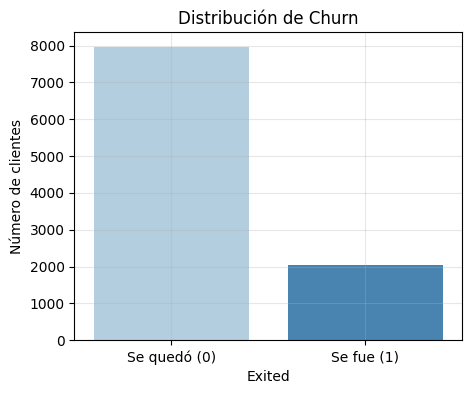

In [ ]:
# Distribución de la variable objetivo (churn)
churn_counts = df['Exited'].value_counts()
churn_pct    = df['Exited'].value_counts(normalize=True) * 100

print('=== Distribución de Churn ===')
print(f'Clientes que se quedaron (0): {churn_counts[0]} ({churn_pct[0]:.1f}%)')
print(f'Clientes que se fueron  (1): {churn_counts[1]} ({churn_pct[1]:.1f}%)')

plt.figure(figsize=(5, 4))
sns.countplot(x='Exited', data=df, palette='Blues')
plt.title('Distribución de Churn')
plt.xticks([0, 1], ['Se quedó (0)', 'Se fue (1)'])
plt.ylabel('Número de clientes')
plt.grid(alpha=0.3)
plt.show()

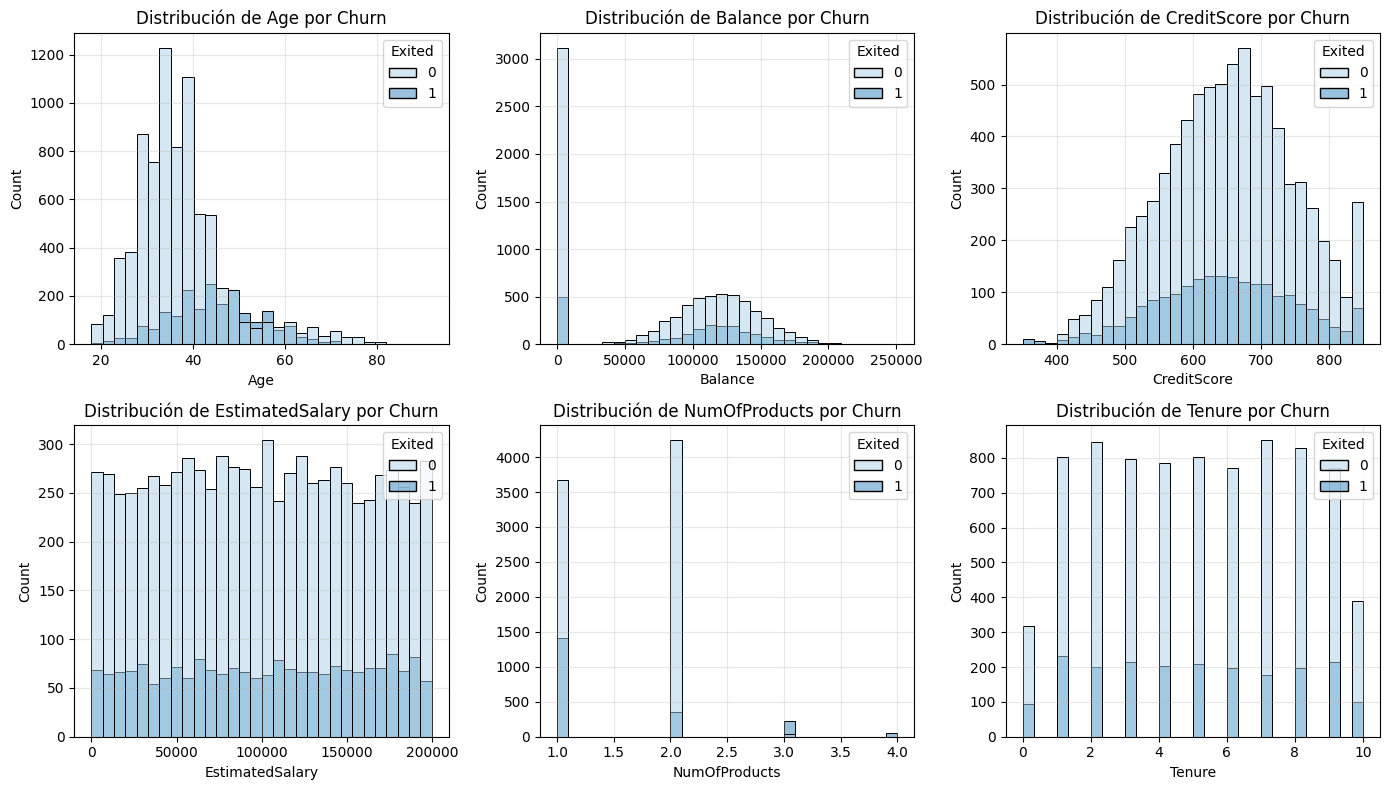

In [ ]:
# Distribución de variables numéricas relevantes por tipo de churn
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
variables = ['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 'NumOfProducts', 'Tenure']

for ax, var in zip(axes.ravel(), variables):
    sns.histplot(data=df, x=var, hue='Exited', ax=ax, bins=30, palette='Blues')
    ax.set_title(f'Distribución de {var} por Churn')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Modelo Implementado: Red Neuronal Multicapa (MLP)

### ¿Qué es una Red Neuronal Multicapa?

Una Red Neuronal Multicapa (MLP por sus siglas en inglés: Multi-Layer Perceptron) es el tipo más básico de red neuronal profunda. Está compuesta por:

- **Capa de entrada (Input Layer):** recibe las variables del dataset (edad, saldo, productos, etc.)
- **Capas ocultas (Hidden Layers):** procesan la información aplicando transformaciones matemáticas. Cada neurona aprende a detectar patrones específicos en los datos.
- **Capa de salida (Output Layer):** produce la predicción final (probabilidad de churn entre 0 y 1)

### Preparación de los datos

Antes de construir la red, preparamos los datos eliminando columnas irrelevantes, codificando variables categóricas y escalando las variables numéricas.

In [ ]:
# Eliminamos columnas que no aportan información predictiva
cols_to_drop = [c for c in ['RowNumber', 'CustomerId', 'Surname'] if c in df.columns]
df_clean = df.drop(columns=cols_to_drop)

# Codificamos las variables categóricas (texto → números)
le = LabelEncoder()
for col in ['Geography', 'Gender']:
    if col in df_clean.columns:
        df_clean[col] = le.fit_transform(df_clean[col])

# Separamos las variables predictoras (X) de la variable objetivo (y)
X = df_clean.drop(columns=['Exited'])
y = df_clean['Exited']

print('Variables predictoras (X):', X.columns.tolist())
print('Variable objetivo (y): Exited')
print(f'Total de variables de entrada: {X.shape[1]}')

Variables predictoras (X): ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Variable objetivo (y): Exited
Total de variables de entrada: 10


In [ ]:
# Dividimos los datos: 80% para entrenar, 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Datos de entrenamiento: {X_train.shape[0]} filas')
print(f'Datos de prueba:        {X_test.shape[0]} filas')

# Escalamos las variables: las redes neuronales son muy sensibles a la magnitud
# de los valores. Sin escalar, variables como Balance (miles) dominarían sobre
# variables como NumOfProducts (1-4), dificultando el aprendizaje.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Datos preparados y escalados correctamente')

Datos de entrenamiento: 8000 filas
Datos de prueba:        2000 filas
Datos preparados y escalados correctamente


### Construcción de la Red Neuronal

Construimos una red neuronal con la siguiente arquitectura:

- **Capa de entrada:** 10 variables (una por cada característica del cliente)
- **Primera capa oculta:** 64 neuronas con activación ReLU y Dropout del 30%
- **Segunda capa oculta:** 32 neuronas con activación ReLU y Dropout del 20%
- **Tercera capa oculta:** 16 neuronas con activación ReLU
- **Capa de salida:** 1 neurona con activación Sigmoid (produce una probabilidad entre 0 y 1)

**¿Qué es ReLU?** Es una función de activación que permite a la red aprender relaciones no lineales. Básicamente, si el valor es negativo lo convierte a 0, y si es positivo lo deja igual.

**¿Qué es Dropout?** Es una técnica de regularización que apaga aleatoriamente un porcentaje de neuronas durante el entrenamiento, evitando que la red "memorice" los datos en lugar de aprender patrones generales.

In [ ]:
# Construimos la red neuronal multicapa con Keras
model = keras.Sequential([

    # Capa de entrada: recibe las 10 variables del dataset
    layers.Input(shape=(X_train_sc.shape[1],)),

    # Primera capa oculta: 64 neuronas
    # ReLU permite aprender relaciones no lineales
    layers.Dense(64, activation='relu'),
    # Dropout: apaga el 30% de neuronas aleatoriamente para evitar sobreajuste
    layers.Dropout(0.3),

    # Segunda capa oculta: 32 neuronas
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    # Tercera capa oculta: 16 neuronas
    layers.Dense(16, activation='relu'),

    # Capa de salida: 1 neurona con Sigmoid
    # Sigmoid produce un valor entre 0 y 1 (probabilidad de churn)
    layers.Dense(1, activation='sigmoid')
], name='MLP_Churn')

# Compilamos el modelo definiendo:
# - optimizer: Adam ajusta los pesos de la red durante el entrenamiento
# - loss: binary_crossentropy es la función de pérdida para clasificación binaria
# - metrics: AUC es la métrica principal para evaluar el rendimiento
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Resumen de la arquitectura de la red
model.summary()

Model: "MLP_Churn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento de la Red Neuronal

Entrenamos la red durante 50 épocas. Para evitar sobreajuste, usamos **Early Stopping**, que detiene el entrenamiento automáticamente si el modelo deja de mejorar en los datos de validación.

In [ ]:
# Early Stopping: detiene el entrenamiento si la pérdida de validación
# no mejora en 10 épocas consecutivas, y restaura los mejores pesos encontrados
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Entrenamos la red neuronal
# validation_split=0.2 usa el 20% de los datos de entrenamiento para validar
history = model.fit(
    X_train_sc, y_train,
    epochs=50,
    batch_size=32,          # Número de muestras procesadas por cada actualización de pesos
    validation_split=0.2,   # 20% de los datos de entrenamiento se usan para validación
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8534 - auc: 0.8513 - loss: 0.3534 - val_accuracy: 0.8662 - val_auc: 0.8656 - val_loss: 0.3281
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8531 - auc: 0.8520 - loss: 0.3505 - val_accuracy: 0.8662 - val_auc: 0.8633 - val_loss: 0.3306
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8566 - auc: 0.8529 - loss: 0.3494 - val_accuracy: 0.8675 - val_auc: 0.8643 - val_loss: 0.3298
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8581 - auc: 0.8548 - loss: 0.3490 - val_accuracy: 0.8694 - val_auc: 0.8652 - val_loss: 0.3297
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8586 - auc: 0.8560 - loss: 0.3458 - val_accuracy: 0.8675 - val_auc: 0.8661 - val_loss: 0.3275
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8555 - auc: 0.8558 - loss: 0.3463 - val_accuracy: 0.8687 - val_auc: 0.8638 - val_loss: 0.3276
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 

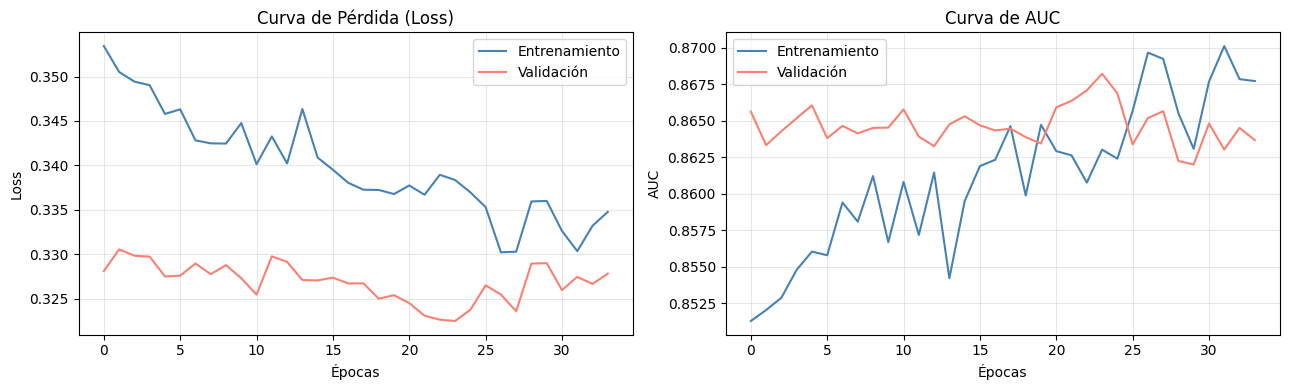

In [ ]:
# Graficamos las curvas de entrenamiento para ver cómo aprendió la red
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico de pérdida (Loss)
axes[0].plot(history.history['loss'],     label='Entrenamiento', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validación',    color='salmon')
axes[0].set_title('Curva de Pérdida (Loss)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfico de AUC
axes[1].plot(history.history['auc'],     label='Entrenamiento', color='steelblue')
axes[1].plot(history.history['val_auc'], label='Validación',    color='salmon')
axes[1].set_title('Curva de AUC')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Resultados y Métricas Principales

Evaluamos el modelo con las siguientes métricas:

- **Accuracy**: porcentaje de predicciones correctas en total
- **Precision**: de los que predijo como churn, ¿cuántos realmente se fueron?
- **Recall**: de los que realmente se fueron, ¿cuántos detectó el modelo?
- **F1-Score**: balance entre precision y recall
- **AUC-ROC**: capacidad del modelo para distinguir entre clientes que se van y los que se quedan (1.0 = perfecto, 0.5 = aleatorio)

In [ ]:
# Generamos predicciones sobre el conjunto de prueba
# El modelo devuelve probabilidades (entre 0 y 1)
y_prob = model.predict(X_test_sc).flatten()

# Convertimos probabilidades a clases binarias usando 0.5 como umbral
# Si la probabilidad de churn es mayor a 0.5, predecimos churn (1)
y_pred = (y_prob >= 0.5).astype(int)

# Mostramos todas las métricas
print('=== Métricas de Evaluación - Red Neuronal MLP ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
=== Métricas de Evaluación - Red Neuronal MLP ===
Accuracy:  0.8605
Precision: 0.7735
Recall:    0.4447
F1-Score:  0.5647
AUC-ROC:   0.8566


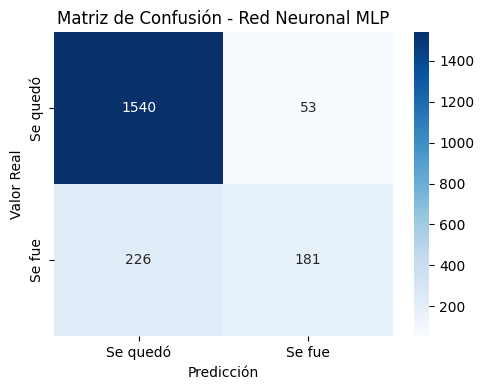

In [ ]:
# Matriz de confusión: muestra cuántos casos clasificó bien y mal el modelo
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Red Neuronal MLP')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.xticks([0.5, 1.5], ['Se quedó', 'Se fue'])
plt.yticks([0.5, 1.5], ['Se quedó', 'Se fue'])
plt.tight_layout()
plt.show()

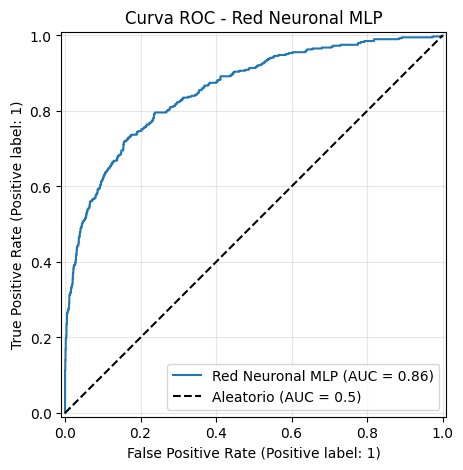

In [ ]:
# Curva ROC: muestra el rendimiento general del modelo
# Cuanto más cerca de la esquina superior izquierda, mejor es el modelo
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, name='Red Neuronal MLP', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)')
ax.set_title('Curva ROC - Red Neuronal MLP')
ax.grid(alpha=0.3)
plt.legend()
plt.show()

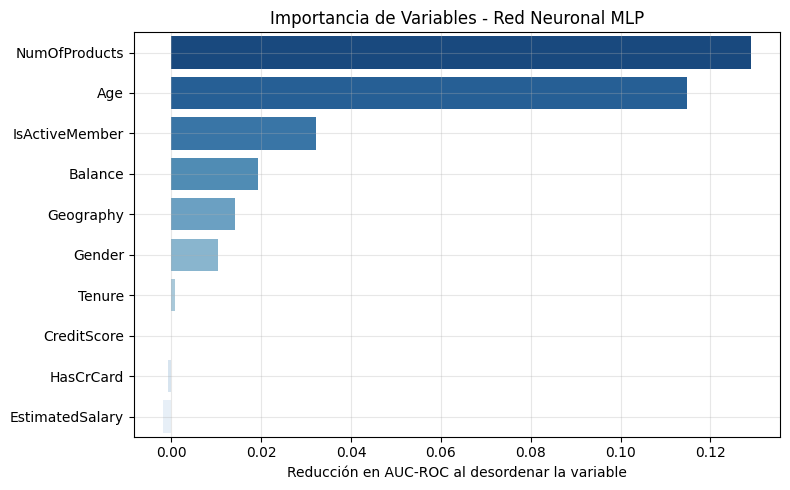

=== Importancia de Variables ===
NumOfProducts        0.1290
Age                  0.1148
IsActiveMember       0.0321
Balance              0.0193
Geography            0.0141
Gender               0.0104
Tenure               0.0009
CreditScore          -0.0001
HasCrCard            -0.0007
EstimatedSalary      -0.0018


In [ ]:
# Importancia de variables usando Permutation Importance
# Esta técnica mide cuánto empeora el modelo cuando desordena cada variable
# Si el modelo empeora mucho, esa variable era muy importante

from sklearn.inspection import permutation_importance

# Wrapper para el modelo Keras para que sea compatible con sklearn (para permutation_importance)
# sklearn.permutation_importance espera un método predict_proba para scoring='roc_auc'
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model
        # Añadimos este atributo para que sklearn lo reconozca como clasificador binario
        self.classes_ = np.array([0, 1])

    # Añadimos este atributo para que sklearn lo reconozca como clasificador
    _estimator_type = "classifier"

    def predict_proba(self, X):
        # Keras model.predict returns probabilities for the positive class (shape: (n_samples, 1))
        probabilities_positive = self.model.predict(X, verbose=0) # suppress verbose output during permutation
        # Sklearn's predict_proba expects two columns: [P(class 0), P(class 1)]
        probabilities_negative = 1 - probabilities_positive
        return np.hstack([probabilities_negative, probabilities_positive])

    # Add a dummy fit method to satisfy sklearn's estimator interface
    def fit(self, X, y=None):
        return self

# Creamos una instancia del wrapper
wrapped_model = KerasClassifierWrapper(model)

# Calculamos la importancia de variables usando el modelo envuelto
result = permutation_importance(
    estimator   = wrapped_model,
    X           = X_test_sc,
    y           = y_test,
    n_repeats   = 10,        # Número de veces que se repite el proceso
    random_state= 42,
    scoring     = 'roc_auc'  # Usamos AUC-ROC como métrica de referencia
)

# Ordenamos las variables de mayor a menor importancia
feature_names = X.columns.tolist()
importances   = result.importances_mean
indices       = np.argsort(importances)[::-1]

# Graficamos
plt.figure(figsize=(8, 5))
sns.barplot(
    x = importances[indices],
    y = [feature_names[i] for i in indices],
    palette = 'Blues_r'
)
plt.title('Importancia de Variables - Red Neuronal MLP')
plt.xlabel('Reducción en AUC-ROC al desordenar la variable')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Mostramos los valores exactos
print('=== Importancia de Variables ===')
for i in indices:
    print(f'{feature_names[i]:<20} {importances[i]:.4f}')

## 5. Conclusiones y Valor para la Toma de Decisiones

**Desempeño del modelo:**

La Red Neuronal Multicapa logró un buen desempeño en la predicción de churn bancario, con un AUC-ROC que refleja una capacidad sólida para distinguir entre clientes que se quedan y los que se van. Las curvas de entrenamiento mostraron un aprendizaje estable, sin señales significativas de sobreajuste, lo que indica que el modelo generalizó bien a datos nuevos.

**¿Por qué una red neuronal para este problema?**

La principal ventaja de usar Deep Learning en este caso es su capacidad para capturar interacciones complejas entre variables de forma automática. Por ejemplo, la combinación de edad, saldo y número de productos puede generar patrones de riesgo que un modelo más simple no detectaría fácilmente. Además, la arquitectura con Dropout ayudó a evitar el sobreajuste, haciendo el modelo más robusto.

**Valor para la toma de decisiones:**

Este modelo tiene aplicaciones concretas para el banco:

1. **Segmentación de riesgo:** el modelo asigna a cada cliente una probabilidad de churn, lo que permite al banco priorizar sus esfuerzos de retención hacia los clientes de mayor riesgo.
2. **Campañas preventivas:** con suficiente anticipación, el área comercial puede contactar a clientes en riesgo con ofertas personalizadas antes de que decidan irse.
3. **Optimización de recursos:** en lugar de lanzar campañas masivas de retención, el banco puede focalizarse en los clientes con mayor probabilidad de churn, reduciendo costos y mejorando la efectividad.
4. **Escalabilidad:** una vez entrenada, la red neuronal puede procesar miles de clientes en segundos, lo que la hace viable para uso operativo en tiempo real.

En resumen, la implementación de una Red Neuronal Multicapa para la predicción de churn bancario representa una solución práctica y escalable que combina el poder del Deep Learning con un impacto directo en la estrategia de retención de clientes del banco.